In [25]:
import pandas as pd
import numpy as np


from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
ratings = pd.read_csv(r"C:\Users\Welcome\Downloads\ml exp 9 dataset\ml-latest-small\ratings.csv")
movies = pd.read_csv(r"C:\Users\Welcome\Downloads\ml exp 9 dataset\ml-latest-small\movies.csv")

In [27]:
ratings.head()

ratings.info()

ratings.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [28]:
item_user_matrix = ratings.pivot(index="movieId",
                                 columns="userId",
                                 values="rating")

In [29]:
item_user_matrix = ratings.pivot(index='movieId', columns='userId', values='rating')

In [30]:
item_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
item_user_matrix_filled = item_user_matrix.fillna(0)

In [32]:
item_similarity = cosine_similarity(item_user_matrix_filled)

In [33]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

In [34]:
similar_movies = item_similarity_df[1].sort_values(ascending=False)[1:6]

print(similar_movies)

movieId
3114    0.572601
480     0.565637
780     0.564262
260     0.557388
356     0.547096
Name: 1, dtype: float64


In [35]:
user_ratings = item_user_matrix[1]
rated_movies = user_ratings[user_ratings > 0].index

In [36]:
recommendations = {}

for movie in rated_movies:
    similar = item_similarity_df[movie].sort_values(ascending=False)[1:6]
    
    for sim_movie, score in similar.items():
        if sim_movie not in rated_movies:
            recommendations[sim_movie] = recommendations.get(sim_movie, 0) + score

In [37]:
recommended_movies = sorted(recommendations.items(),
                            key=lambda x: x[1],
                            reverse=True)

print(recommended_movies[:10])

[(2918, 6.226053115904851), (380, 5.310791980664414), (2087, 3.5215855497847466), (1527, 3.433625121065828), (318, 3.3233564775541202), (589, 3.3095511951179644), (3633, 2.7351487145517384), (3704, 2.722408829451948), (1129, 2.6464823410902953), (2081, 2.6087308997505576)]


In [44]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

true_ratings = ratings['rating'].iloc[:100]
predicted_ratings = np.random.uniform(2,5,100)

rmse = np.sqrt(mean_squared_error(true_ratings, predicted_ratings))

print("RMSE:", rmse)

RMSE: 1.4765078013569735


In [45]:
relevant_recommended_items = 3
K = 5

Precision_K = relevant_recommended_items / K

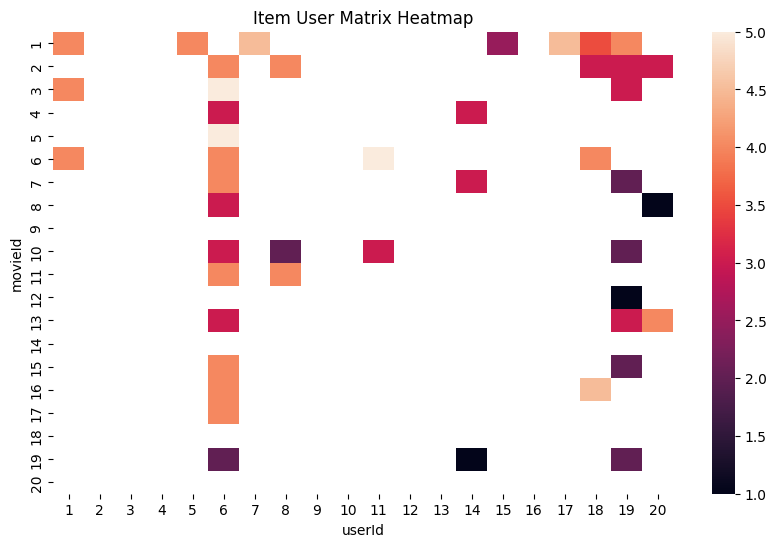

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(item_user_matrix.iloc[:20,:20])
plt.title("Item User Matrix Heatmap")
plt.show()

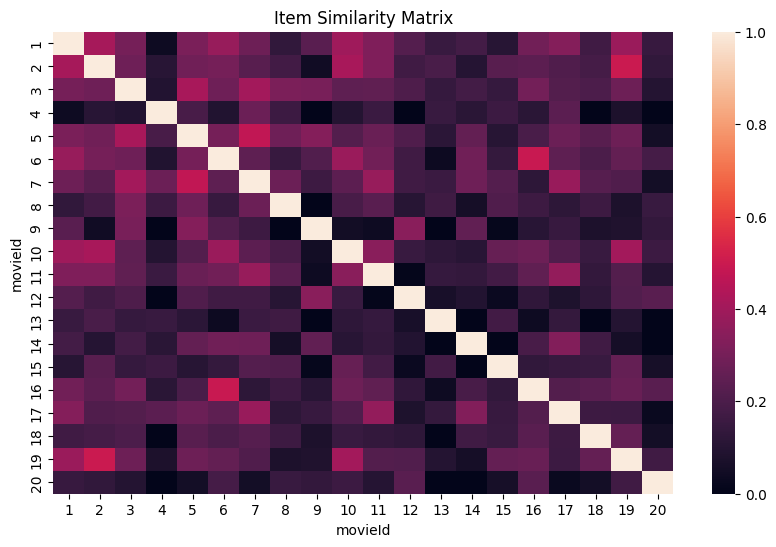

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(item_similarity_df.iloc[:20,:20])
plt.title("Item Similarity Matrix")
plt.show()

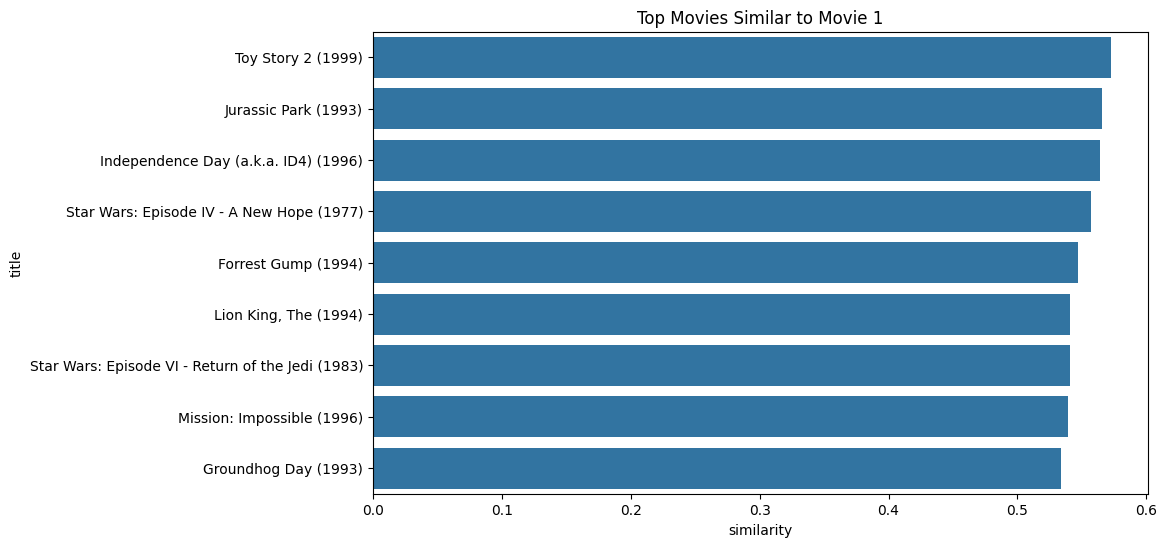

In [46]:
similar_movies = item_similarity_df[1].sort_values(ascending=False)[1:10]

similar_df = pd.DataFrame({
    "movieId": similar_movies.index,
    "similarity": similar_movies.values
})

similar_df = similar_df.merge(movies, on="movieId")

plt.figure(figsize=(10,6))

sns.barplot(x="similarity", y="title", data=similar_df)

plt.title("Top Movies Similar to Movie 1")

plt.show()